# Session 29: Custom Image Classifier Capstone Project
### Duration: ~3 Hours

---

## Capstone Goal

Build an **end-to-end image classification project** with PyTorch and transfer learning.

Business-style question:

> Can we automatically classify animal photos into useful categories using a small labeled dataset and a pretrained CNN?

This capstone mirrors **Session 23** (tabular ML project) but for **computer vision** (Sessions 24–28).

## What This Capstone Reviews

- PyTorch `Dataset`, `DataLoader`, and device setup
- Image transforms and **train vs validation** preprocessing
- Exploratory checks on image data (counts, sample grid)
- Pretrained **MobileNetV2** + replaced classifier head
- **Feature extraction** (frozen backbone) then optional **fine-tuning**
- Training loops, loss/accuracy curves, confusion matrix
- Saving and reloading model weights with `torch.save`
- Writing a short **project memo** for stakeholders

## Dataset

We use **4 classes from CIFAR-10**:

```text
bird, cat, deer, dog
```

CIFAR-10 downloads automatically via `torchvision` (same family as Session 28, but a **multi-class** project).

> **Prerequisites:** Sessions 24–28 (deep learning intro, CNNs, transfer learning).



---
## 1. Project Brief and Success Metrics

| Item | Choice |
|------|--------|
| **Task** | Multi-class image classification |
| **Input** | 32×32 RGB images (resized for MobileNet) |
| **Output** | One of 4 animal classes |
| **Primary metric** | Validation accuracy |
| **Secondary** | Confusion matrix, misclassified examples |
| **Deliverables** | Saved `.pt` model, metrics CSV, project memo |

### End-to-end workflow

```text
1. Load data -> 2. Explore -> 3. Split train/val/test
4. Build transforms -> 5. Load pretrained model -> 6. Train head
7. Optional fine-tune -> 8. Evaluate -> 9. Save -> 10. Predict
```

> **Leakage rule:** Fit transforms on training logic only; pick hyperparameters using **validation**, report **test** once at the end.



In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
from torchvision import datasets, models, transforms
from torchvision.models import MobileNet_V2_Weights

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = Path('data')
OUTPUT_DIR = Path('session29_artifacts')
OUTPUT_DIR.mkdir(exist_ok=True)

print('PyTorch version:', torch.__version__)
print('Torchvision version:', torchvision.__version__)
print('Using device:', DEVICE)
print('Output folder:', OUTPUT_DIR.resolve())



PyTorch version: 2.12.1+cpu
Torchvision version: 0.27.1+cpu
Using device: cpu
Output folder: C:\python_AI_ML\session29_artifacts


---
## 2. Load the Dataset — Four CIFAR-10 Classes

CIFAR-10 original label IDs:

| Class | ID |
|-------|-----|
| bird | 2 |
| cat | 3 |
| deer | 4 |
| dog | 5 |

We sample a **balanced subset** so training stays fast on CPU (~10–20 minutes total).

> On GPU, increase `SAMPLES_PER_CLASS_TRAIN` and epochs for higher accuracy.



In [2]:
IMAGE_SIZE = 96
SAMPLES_PER_CLASS_TRAIN = 120
SAMPLES_PER_CLASS_TEST = 40
VAL_FRACTION = 0.2

CLASS_NAMES = ['bird', 'cat', 'deer', 'dog']
ORIGINAL_TO_NEW = {2: 0, 3: 1, 4: 2, 5: 3}
TARGET_ORIGINAL_IDS = set(ORIGINAL_TO_NEW.keys())

weights = MobileNet_V2_Weights.DEFAULT
preprocess = weights.transforms()

base_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    preprocess,
])

train_full = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=base_transform)
test_full = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=base_transform)


def make_balanced_indices(dataset, class_map, samples_per_class, seed=42):
    rng = np.random.default_rng(seed)
    buckets = {new_id: [] for new_id in class_map.values()}
    for idx, (_, label) in enumerate(dataset):
        if label in class_map:
            buckets[class_map[label]].append(idx)
    selected = []
    for new_id in sorted(buckets):
        pool = buckets[new_id]
        pick = rng.choice(pool, size=min(samples_per_class, len(pool)), replace=False)
        selected.extend(pick.tolist())
    rng.shuffle(selected)
    return selected


class CIFAR10MultiClassSubset(torch.utils.data.Dataset):
    def __init__(self, subset, class_map):
        self.subset = subset
        self.class_map = class_map

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset[index]
        return image, self.class_map[label]


train_indices = make_balanced_indices(train_full, ORIGINAL_TO_NEW, SAMPLES_PER_CLASS_TRAIN)
test_indices = make_balanced_indices(test_full, ORIGINAL_TO_NEW, SAMPLES_PER_CLASS_TEST, seed=43)

train_pool = CIFAR10MultiClassSubset(Subset(train_full, train_indices), ORIGINAL_TO_NEW)
test_dataset = CIFAR10MultiClassSubset(Subset(test_full, test_indices), ORIGINAL_TO_NEW)

val_size = int(len(train_pool) * VAL_FRACTION)
train_size = len(train_pool) - val_size
train_dataset, val_dataset = random_split(
    train_pool,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_STATE),
)

print('Train size:', len(train_dataset))
print('Validation size:', len(val_dataset))
print('Test size:', len(test_dataset))
print('Classes:', CLASS_NAMES)



Train size: 384
Validation size: 96
Test size: 160
Classes: ['bird', 'cat', 'deer', 'dog']


---
## 3. Exploratory Data Checks (Images)

Even in deep learning projects, always inspect:

- Class balance
- Sample images
- Image tensor shape after transforms



class_name  bird  cat  deer  dog
split                           
train         99   97    95   93
val           21   23    25   27


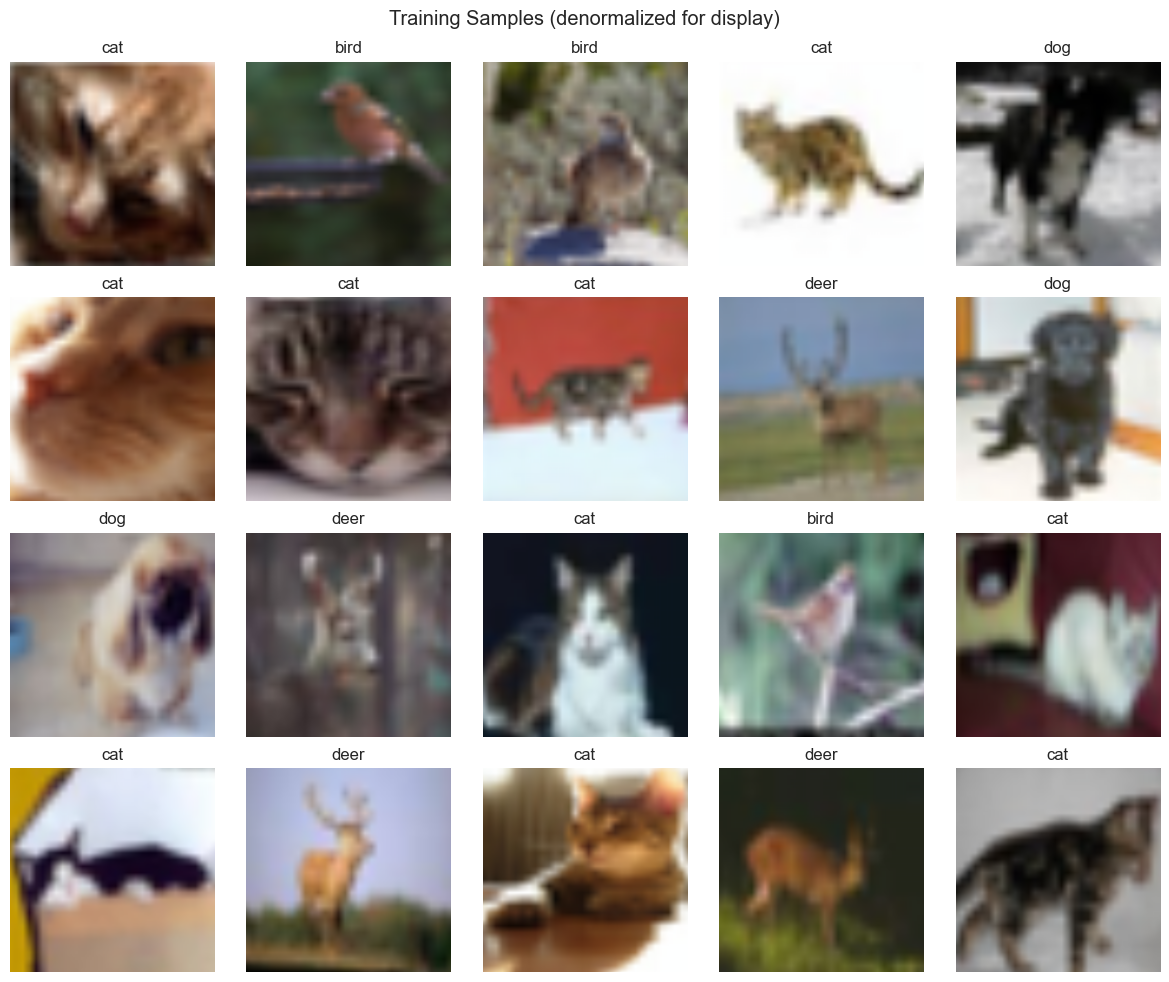

Tensor shape per image: (3, 224, 224)


In [3]:
train_labels = [train_pool[i][1] for i in train_dataset.indices]
val_labels = [train_pool[i][1] for i in val_dataset.indices]

count_df = pd.DataFrame({
    'split': ['train'] * len(train_labels) + ['val'] * len(val_labels),
    'class_id': train_labels + val_labels,
})
count_df['class_name'] = count_df['class_id'].map(dict(enumerate(CLASS_NAMES)))

print(count_df.groupby(['split', 'class_name']).size().unstack(fill_value=0))

sample_loader = DataLoader(train_dataset, batch_size=20, shuffle=True)
images, labels = next(iter(sample_loader))

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for ax, img, lbl in zip(axes.ravel(), images, labels):
    img_show = img.permute(1, 2, 0).numpy()
    mean = np.array(preprocess.mean).reshape(1, 1, 3)
    std = np.array(preprocess.std).reshape(1, 1, 3)
    img_show = np.clip(img_show * std + mean, 0, 1)
    ax.imshow(img_show)
    ax.set_title(CLASS_NAMES[lbl])
    ax.axis('off')
plt.suptitle('Training Samples (denormalized for display)')
plt.tight_layout()
plt.show()

print('Tensor shape per image:', tuple(images.shape[1:]))



---
## 4. Data Augmentation (Training Only)

**Augmentation** creates slightly modified training images (flips) to reduce overfitting.

Validation and test use **only** deterministic preprocessing (no random flips).



In [4]:
class AugmentSubset(torch.utils.data.Dataset):
    """Apply random horizontal flip on tensor images (train only)."""

    def __init__(self, subset, flip_prob=0.0):
        self.subset = subset
        self.flip_prob = flip_prob

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset[index]
        if self.flip_prob > 0 and torch.rand(1).item() < self.flip_prob:
            image = torch.flip(image, dims=[2])
        return image, label


train_dataset_aug = AugmentSubset(train_dataset, flip_prob=0.5)
val_dataset_eval = AugmentSubset(val_dataset, flip_prob=0.0)
test_dataset_eval = AugmentSubset(test_dataset, flip_prob=0.0)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset_eval, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset_eval, batch_size=BATCH_SIZE, shuffle=False)

print('Train batches:', len(train_loader))
print('Val batches:', len(val_loader))
print('Test batches:', len(test_loader))



Train batches: 12
Val batches: 3
Test batches: 5


---
## 5. Build the Transfer Learning Model

Same pattern as Session 28:

1. Load pretrained MobileNetV2
2. Freeze backbone
3. Replace classifier for **4 classes**



In [5]:
NUM_CLASSES = len(CLASS_NAMES)

model = models.mobilenet_v2(weights=weights)
for parameter in model.features.parameters():
    parameter.requires_grad = False

num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, NUM_CLASSES)
model = model.to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print('Trainable parameters:', f'{trainable:,}')
print('Frozen parameters:', f'{frozen:,}')



Trainable parameters: 5,124
Frozen parameters: 2,223,872


---
## 6. Training and Evaluation Helpers



In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    return total_loss / total, correct / total, all_preds, all_labels


criterion = nn.CrossEntropyLoss()



---
## 7. Phase 1 — Train the Classifier Head (Feature Extraction)

Session 28 stopped here. In this capstone we treat this as **baseline training** before optional fine-tuning.



In [7]:
for p in model.features.parameters():
    p.requires_grad = False
for p in model.classifier.parameters():
    p.requires_grad = True

optimizer_head = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
EPOCHS_HEAD = 5
history = []

for epoch in range(1, EPOCHS_HEAD + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_head, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    history.append({
        'phase': 'head_only',
        'epoch': epoch,
        'train_loss': train_loss,
        'train_accuracy': train_acc,
        'val_loss': val_loss,
        'val_accuracy': val_acc,
    })
    print(f'Epoch {epoch:02d} | train acc {train_acc:.3f} | val acc {val_acc:.3f}')

history_df = pd.DataFrame(history)
best_val = history_df['val_accuracy'].max()
print(f'\nBest validation accuracy (head only): {best_val:.3f}')



Epoch 01 | train acc 0.385 | val acc 0.562
Epoch 02 | train acc 0.594 | val acc 0.698
Epoch 03 | train acc 0.680 | val acc 0.750
Epoch 04 | train acc 0.742 | val acc 0.750
Epoch 05 | train acc 0.745 | val acc 0.750

Best validation accuracy (head only): 0.750


---
## 8. Phase 2 — Optional Fine-Tuning (Last Feature Blocks)

**Fine-tuning** unfreezes a small part of the backbone with a **lower learning rate**.

We unfreeze the last MobileNet feature block only — a safe beginner pattern.



In [8]:
for p in model.features[-3:].parameters():
    p.requires_grad = True

optimizer_ft = torch.optim.Adam([
    {'params': model.features[-3:].parameters(), 'lr': 1e-4},
    {'params': model.classifier.parameters(), 'lr': 1e-3},
])

EPOCHS_FT = 3
for epoch in range(1, EPOCHS_FT + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer_ft, DEVICE)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    history.append({
        'phase': 'fine_tune',
        'epoch': EPOCHS_HEAD + epoch,
        'train_loss': train_loss,
        'train_accuracy': train_acc,
        'val_loss': val_loss,
        'val_accuracy': val_acc,
    })
    print(f'FT epoch {epoch:02d} | train acc {train_acc:.3f} | val acc {val_acc:.3f}')

history_df = pd.DataFrame(history)
print('\nBest validation accuracy overall:', history_df['val_accuracy'].max().round(3))



FT epoch 01 | train acc 0.758 | val acc 0.740
FT epoch 02 | train acc 0.802 | val acc 0.760
FT epoch 03 | train acc 0.852 | val acc 0.792

Best validation accuracy overall: 0.792


---
## 9. Plot Training History



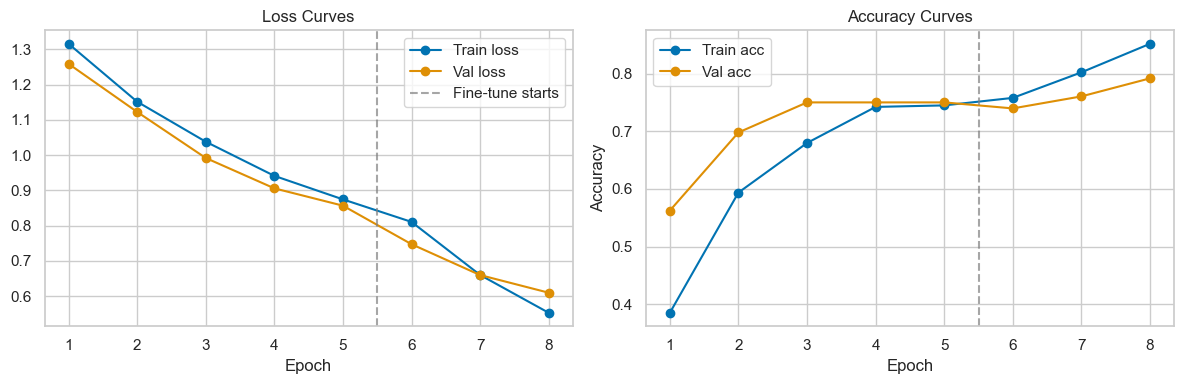

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train loss')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Val loss')
axes[0].axvline(EPOCHS_HEAD + 0.5, color='gray', linestyle='--', alpha=0.7, label='Fine-tune starts')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_accuracy'], marker='o', label='Train acc')
axes[1].plot(history_df['epoch'], history_df['val_accuracy'], marker='o', label='Val acc')
axes[1].axvline(EPOCHS_HEAD + 0.5, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Accuracy Curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()



---
## 10. Final Test Evaluation (Once)

Use the **held-out test set** once after model selection on validation.



Test loss: 0.6875
Test accuracy: 0.744

Classification report:
              precision    recall  f1-score   support

        bird       0.76      0.85      0.80        40
         cat       0.65      0.70      0.67        40
        deer       0.81      0.75      0.78        40
         dog       0.77      0.68      0.72        40

    accuracy                           0.74       160
   macro avg       0.75      0.74      0.74       160
weighted avg       0.75      0.74      0.74       160



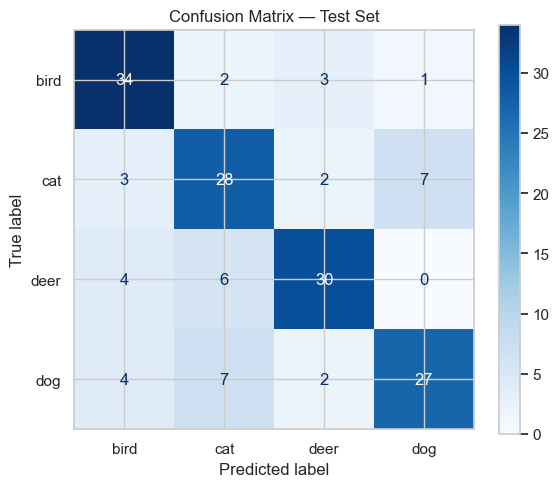

In [10]:
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, DEVICE)

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.3f}')
print('\nClassification report:')
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    test_labels, test_preds, display_labels=CLASS_NAMES, cmap='Blues', ax=ax,
)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()



---
## 11. Inspect Misclassified Images

Understanding **failure modes** is part of every capstone (Session 23 did this for churn).



Misclassified count: 41 of 160


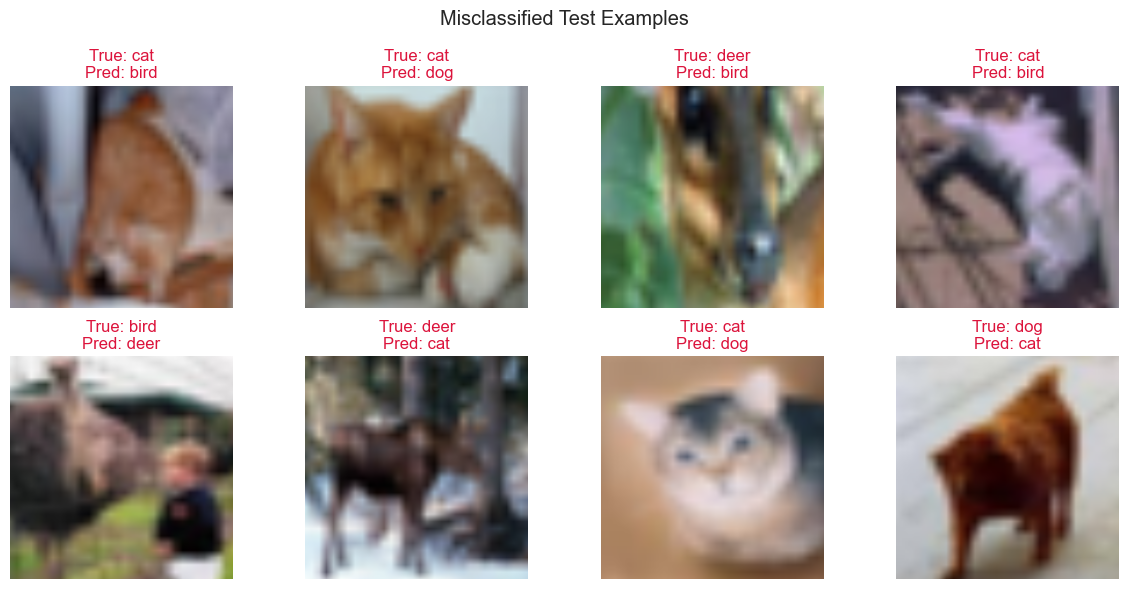

In [11]:
test_images, test_y = next(iter(DataLoader(test_dataset_eval, batch_size=len(test_dataset_eval), shuffle=False)))
test_images = test_images.to(DEVICE)
with torch.no_grad():
    logits = model(test_images)
    pred_ids = logits.argmax(1).cpu().numpy()

mis_idx = np.where(pred_ids != np.array(test_y))[0]
print('Misclassified count:', len(mis_idx), 'of', len(test_y))

show_n = min(8, len(mis_idx))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()
for ax, idx in zip(axes, mis_idx[:show_n]):
    img = test_images[idx].cpu().permute(1, 2, 0).numpy()
    img = np.clip(img * np.array(preprocess.std).reshape(1, 1, 3) + np.array(preprocess.mean).reshape(1, 1, 3), 0, 1)
    true_lbl = CLASS_NAMES[test_y[idx]]
    pred_lbl = CLASS_NAMES[pred_ids[idx]]
    ax.imshow(img)
    ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl}', color='crimson')
    ax.axis('off')
for ax in axes[show_n:]:
    ax.axis('off')
plt.suptitle('Misclassified Test Examples')
plt.tight_layout()
plt.show()



---
## 12. Save Project Artifacts

Save weights + metadata so you can reload without retraining.



In [12]:
metrics_summary = pd.DataFrame([
    {'metric': 'best_val_accuracy', 'value': history_df['val_accuracy'].max()},
    {'metric': 'test_accuracy', 'value': test_acc},
    {'metric': 'num_classes', 'value': NUM_CLASSES},
    {'metric': 'epochs_head', 'value': EPOCHS_HEAD},
    {'metric': 'epochs_fine_tune', 'value': EPOCHS_FT},
])

model_path = OUTPUT_DIR / 'cifar10_animals_mobilenetv2.pt'
history_path = OUTPUT_DIR / 'training_history.csv'
metrics_path = OUTPUT_DIR / 'project_metrics.csv'

save_package = {
    'model_state_dict': model.state_dict(),
    'class_names': CLASS_NAMES,
    'image_size': IMAGE_SIZE,
    'architecture': 'mobilenet_v2',
    'num_classes': NUM_CLASSES,
}

torch.save(save_package, model_path)
history_df.to_csv(history_path, index=False)
metrics_summary.to_csv(metrics_path, index=False)

print('Saved model:', model_path)
print('Saved history:', history_path)
print('Saved metrics:', metrics_path)
print(metrics_summary.to_string(index=False))



Saved model: session29_artifacts\cifar10_animals_mobilenetv2.pt
Saved history: session29_artifacts\training_history.csv
Saved metrics: session29_artifacts\project_metrics.csv
           metric    value
best_val_accuracy 0.791667
    test_accuracy 0.743750
      num_classes 4.000000
      epochs_head 5.000000
 epochs_fine_tune 3.000000


---
## 13. Reload Model and Run Inference

Simulates deployment: load saved weights and predict one batch.



In [13]:
checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)

reload_model = models.mobilenet_v2(weights=None)
reload_model.classifier[1] = nn.Linear(
    reload_model.classifier[1].in_features,
    checkpoint['num_classes'],
)
reload_model.load_state_dict(checkpoint['model_state_dict'])
reload_model = reload_model.to(DEVICE)
reload_model.eval()

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images.to(DEVICE)
with torch.no_grad():
    probs = torch.softmax(reload_model(sample_images), dim=1).cpu().numpy()

example_idx = 0
print('Example prediction')
print('  True class:', CLASS_NAMES[sample_labels[example_idx]])
for i, name in enumerate(CLASS_NAMES):
    print(f'  P({name}) = {probs[example_idx, i]:.3f}')



Example prediction
  True class: dog
  P(bird) = 0.018
  P(cat) = 0.032
  P(deer) = 0.002
  P(dog) = 0.948


---
## 14. Project Memo Template

Fill this in after running the notebook (good portfolio habit):

1. **Problem** — What are we classifying and why?
2. **Data** — Source, classes, train/val/test sizes
3. **Model** — Pretrained backbone, head-only vs fine-tuned
4. **Results** — Best val accuracy, final test accuracy
5. **Errors** — Which classes confuse each other?
6. **Next steps** — More data, stronger augmentation, GPU training, deployment

---

## Practice Exercises

1. Train **head only** (skip fine-tuning). How much does test accuracy change?
2. Remove `RandomHorizontalFlip` — does validation accuracy drop?
3. Try 2 classes only (cat vs dog, like Session 28). Is the project easier?
4. Change `SAMPLES_PER_CLASS_TRAIN` to 100 — how do metrics change?
5. Save misclassified indices to a CSV in `session29_artifacts/`.
6. Write the 6-bullet memo for a non-technical stakeholder.

---

## Session 29 Summary

| Step | Takeaway |
|------|----------|
| **Project framing** | Define metric and deliverables first |
| **Data checks** | Balance + visual samples before training |
| **Transfer learning** | Pretrained MobileNetV2 + new head |
| **Two-phase training** | Head first, then careful fine-tune |
| **Evaluation** | Validation for decisions; test once |
| **Artifacts** | `torch.save` package with class names |

### Key gotchas

- **Test set** is for final reporting only
- **Augmentation** on train only — never on val/test
- **Fine-tuning** needs smaller LR on backbone
- Low-resolution CIFAR images are hard — real projects use larger photos

### Next Session

**Session 30**: Introduction to RNNs and LSTM — sequence data, text preprocessing, and LSTM classification with a sklearn baseline.

